# Framework to Buy (determine Price Direction in hierarchy)

* Capital Flows: Risk-On / Off - currency mkt, index vol (DVOL,VNX,VIX), global liquidity (money markets, Howell), FRB moves
 - ‘The dollar is the basis of everything’
 - Yield curve steep - growth (innovation)
 - Yield curve flat or inverted - value (cash-generating)
 - Relative sector moves - NDX / SPY (XLP, XLY, …)

* Sector / Industry Leadership - review top N largest firms in sectors
 - ‘What is working now?’
 - Gamma indicators - EMA, RSI, MACD
 - Denominated by vol -
 - …

* Individual Stock -
 - ‘Gauge the range and probability of price moves’
 - falling volatility is rising momentum in current direction
 - "volatility compression" to incompressibly low levels, which signals an imminent and powerful move.
 - Seek the "land of alpha", defined as areas of "low and rising volatility" or "rising skew" (the third derivative of price)

* Timing and Entrance
 - confluence across multiple technical vectors - such as all-time high monthly closes, Fibonacci extensions, and RSI momentum
 - Don’t catch a falling knife
 - A stock only becomes a "buy" when the decline of the rate of decline starts to accelerate, signaling the bottoming process
 - Slowly enter so that you are 60% in when it is 33% into its bounds

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ..

/workspaces/API-macroecon-wrappy


In [2]:
import sys
sys.path.append('/workspaces/API-macroecon-wrappy')

In [3]:
from macroecon_wrappy import Auth

import pandas as pd
import yfinance as yf
import alpha_vantage as av

from pathlib import Path


secrets_path = Path('/workspaces/API-macroecon-wrappy/SECRETS.yaml')
cache_path = Path('/workspaces/API-macroecon-wrappy/tests/tmp/')
auth = Auth(secrets_path, cache_path)
auth.load_secrets()

True

In [4]:
#project
from macroecon_wrappy import (
    Auth,
    Metric,
    Measure,
    Epoch,
    plots
)
from macroecon_wrappy.adapters import (
    YahooFin
)

#external
import yfinance as yf

#system
from pathlib import Path

In [18]:
#yahoo
YahooFin.set_wrapper(auth, yf)
rkt = YahooFin.get_data(tickers='RKT')
#df = pd.DataFrame(rkt, columns=['rkt'])

/workspaces/API-macroecon-wrappy/macroecon_wrappy/adapters/yahoo.py:112: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  1 of 1 completed
/workspaces/API-macroecon-wrappy/.venv/lib/python3.12/site-packages/yfinance/scrapers/fundamentals.py:36: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.


Have not implemented fetching 'shares' from Yahoo API


### Capital Flows: Risk-On / Off - currency mkt, index vol (DVOL,VNX,VIX), global liquidity (money markets, Howell), FRB moves

* ‘The dollar is the basis of everything’
* Yield curve steep - growth (innovation)
* Yield curve flat or inverted - value (cash-generating)
* Relative sector moves - NDX / SPY (XLP, XLY, …)

### Sector / Industry Leadership - review top N largest firms in sectors

* ‘What is working now?’
* Gamma indicators - EMA, RSI, MACD
* Denominated by vol -
* …

### Individual Stock -

* ‘Gauge the range and probability of price moves’
* falling volatility is rising momentum in current direction
* "volatility compression" to incompressibly low levels, which signals an imminent and powerful move.
* Seek the "land of alpha", defined as areas of "low and rising volatility" or "rising skew" (the third derivative of price)

### Timing and Entrance

* confluence across multiple technical vectors - such as all-time high monthly closes, Fibonacci extensions, and RSI momentum
* Don’t catch a falling knife
* A stock only becomes a "buy" when the decline of the rate of decline starts to accelerate, signaling the bottoming process
* Slowly enter so that you are 60% in when it is 33% into its bounds

In [5]:
data = yf.download('RKT', period="max")
data.sort_index(ascending=False).head()

/tmp/ipykernel_51751/4125685928.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RKT,RKT,RKT,RKT,RKT
Date,,,,,
2026-03-02,16.790001,17.650000,16.639999,17.570000,37090500
2026-02-27,18.190001,18.490000,17.450001,18.100000,54272200
2026-02-26,17.770000,17.870001,17.225000,17.299999,22269200
2026-02-25,17.330000,17.850000,16.969999,17.850000,33905400
2026-02-24,17.709999,17.750000,16.580000,16.900000,23899400


In [6]:
ts = pd.Series(
    [item[0] for item in data['Close'].values.tolist()], 
    index=data['Close'].index
    )
metric1 = Metric(ts)
metric1.set_metadata(title='rkt')

In [7]:
metric1.ema(span=20)
metric1.returns(type='log').moment_values(type='VOL')
metric1.returns(type='log').moment_values(type='SKW')

timestamp
2020-08-06         NaN
2020-08-07         NaN
2020-08-10         NaN
2020-08-11         NaN
2020-08-12         NaN
                ...   
2026-02-24   -5.434666
2026-02-25   -4.900693
2026-02-26   -5.286607
2026-02-27   -5.777691
2026-03-02   -4.437083
Length: 1398, dtype: float64

In [67]:
from plotnine import ggplot, aes, geom_line, labs, ylim, scale_x_datetime, theme#, figure_size

#'date' is the time variable, 'value' is the measured value, 'series_id' identifies the series
df = pd.DataFrame({
    "date": data['Close'].index,
    "price": metric1.values,
    "ema": metric1.ema(span=20),
    "vol": metric1.returns(type='log').moment_values(type='VOL'),
    "skw": metric1.returns(type='log').moment_values(type='SKW')
})

df['price'] = df['price'] * 3
df['ema'] = df['ema'] * 3
df['vol'] = df['vol'] * 100
df['skw'] = df['skw'] * 5
df.tail()

,date,price,ema,vol,skw
timestamp,,,,,
2026-02-24,2026-02-24,53.129997,56.784043,79.741903,-27.173330
2026-02-25,2026-02-25,51.990000,56.327468,79.678681,-24.503463
2026-02-26,2026-02-26,53.310001,56.040090,80.581787,-26.433035
2026-02-27,2026-02-27,54.570002,55.900082,81.280883,-28.888454
2026-03-02,2026-03-02,50.370003,55.373407,85.135273,-22.185415


In [71]:
df_long = pd.melt(df, id_vars='date', value_vars=['price','ema','vol','skw'], var_name='variable', value_name='value')
df_long.head()

,date,variable,value
0,2020-08-06,price,54.219343
1,2020-08-07,price,62.764366
2,2020-08-10,price,54.622650
3,2020-08-11,price,51.875130
4,2020-08-12,price,50.413153


In [72]:
start_lim = pd.to_datetime('2025-01-01')
end_lim = pd.to_datetime('2026-04-01')

plt = (
    ggplot(df_long, aes(x="date", y="value", color="variable"))  #map 'series_id' to color
    + geom_line()  #add the line layer
    + labs(title="Multi-Line Time Series Plot",
           x="Date",
           y="Value",
           color="Series") #customize labels
    + ylim(-25, 100)
    + scale_x_datetime(limits=(start_lim, end_lim))
    + theme(figure_size=(10, 4)) 
)

/workspaces/API-macroecon-wrappy/.venv/lib/python3.12/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1108 rows containing missing values.


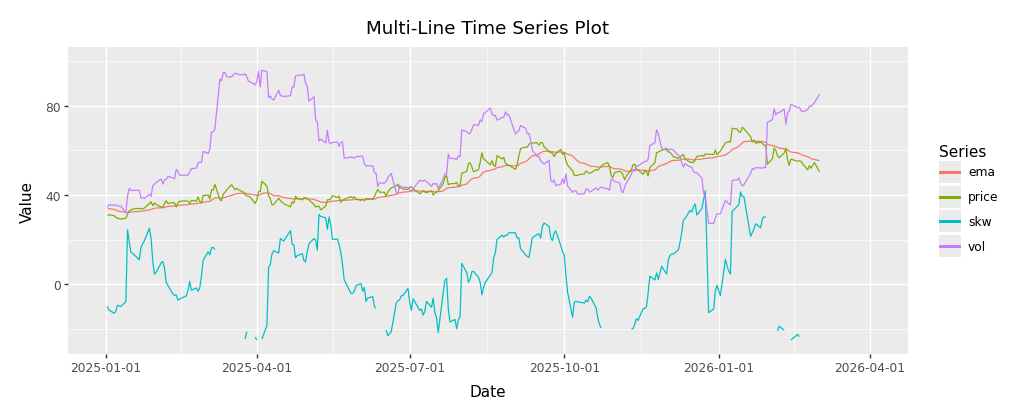

In [73]:
#print(plt)
plt.draw()

ts = av.timeseries.TimeSeries(key=auth.data['alpha_vantage_api_key'])
#data, meta_data = ts.get_intraday('NVDA')  => premium
data, meta_data = ts.get_daily('RKT')

In [5]:
rkt = yf.Ticker('RKT')
print( f'{rkt.info['sector']} / {rkt.info['industry']}' )
rkt.info

Financial Services / Mortgage Finance


{'address1': '1050 Woodward Avenue',
 'city': 'Detroit',
 'state': 'MI',
 'zip': '48226',
 'country': 'United States',
 'phone': '313 373 7990',
 'website': 'https://www.rocketcompanies.com',
 'industry': 'Mortgage Finance',
 'industryKey': 'mortgage-finance',
 'industryDisp': 'Mortgage Finance',
 'sector': 'Financial Services',
 'sectorKey': 'financial-services',
 'sectorDisp': 'Financial Services',
 'longBusinessSummary': 'Rocket Companies, Inc., provides spanning mortgage, real estate, and personal finance services in the United States and Canada. It operates through two segments, Direct to Consumer and Partner Network. The company offers Rocket Mortgage, a mortgage lender service; Rocket Close, an appraisal management, settlement, and title service; Rocket Homes, a home search platform and real estate agent referral network that provides technology-enabled services to support the home buying and selling experience; and Rocket Loans, an online-based personal loans business. It also 

In [6]:
type(rkt)

yfinance.ticker.Ticker

In [ ]:
#yahoo
YahooFin.set_wrapper(auth, yf)
msft = YahooFin.get_data(tickers='MSFT')
df = pd.DataFrame(msft, columns=['msft'])